- ## Ejercicio 1
- *a) Introducir los datos de la tabla en Python con el formato tasks = { "A": {"dur": 2, "deps": []}*

In [1]:
# datos para trabajar
datos = {
    "A": {"dur":2, "deps": []},
    "B": {"dur":4, "deps": ["A"]},
    "C": {"dur":3, "deps": ["B"]},
    "D": {"dur":2, "deps": ["A"]},
    "E": {"dur":3, "deps": ["C", "D"]},
    "F": {"dur":2, "deps": ["E"]},
}

- b) Calcular los tiempos de inicio temprano, de final temprano, de inicio tardío y de final tardío para cada una de las tareas, creando funciones que realicen el cálculo automáticamente.
    - **IC:** Inicio temprano/cercano = Mirar las tareas anteriores (duración)
    - **TC:** Término cercano/final temprano = *IC* + duración de su tarea
    - **IL:** Inicio lejano/tardío = *TL (mayor)* - Duración (restar duración desde el final)
    - **TL:** Término lejano/final tardío = De fina a Inicio, mirar las TC de la última tarea = TL, luego para las predecesoras = IC del sucesor mayor

In [2]:
# IC
def calcular_inicio_temprano(datos):
    for tarea,info in datos.items():
        dependencias = info["deps"]

        if not dependencias:
            datos[tarea]["IC"]=0
        else:
            lista_tareas=[]
            for dep in dependencias:
                inicio=datos[dep]["dur"]+datos[dep]["IC"]
                lista_tareas.append(inicio)
            datos[tarea]["IC"]=max(lista_tareas)
calcular_inicio_temprano(datos)
print(datos)

{'A': {'dur': 2, 'deps': [], 'IC': 0}, 'B': {'dur': 4, 'deps': ['A'], 'IC': 2}, 'C': {'dur': 3, 'deps': ['B'], 'IC': 6}, 'D': {'dur': 2, 'deps': ['A'], 'IC': 2}, 'E': {'dur': 3, 'deps': ['C', 'D'], 'IC': 9}, 'F': {'dur': 2, 'deps': ['E'], 'IC': 12}}


- **TC:** Término cercano/final temprano = *IC* + duración de su tarea

In [3]:
# TC
def calcular_final_temprano(datos):
    for tarea,info in datos.items():
        datos[tarea]["TC"]=datos[tarea]["dur"]+datos[tarea]["IC"]
calcular_final_temprano(datos)
print(datos)

{'A': {'dur': 2, 'deps': [], 'IC': 0, 'TC': 2}, 'B': {'dur': 4, 'deps': ['A'], 'IC': 2, 'TC': 6}, 'C': {'dur': 3, 'deps': ['B'], 'IC': 6, 'TC': 9}, 'D': {'dur': 2, 'deps': ['A'], 'IC': 2, 'TC': 4}, 'E': {'dur': 3, 'deps': ['C', 'D'], 'IC': 9, 'TC': 12}, 'F': {'dur': 2, 'deps': ['E'], 'IC': 12, 'TC': 14}}


- **TL:** Término lejano/final tardío = De fina a Inicio, mirar las TC de la última tarea = TL, luego para las predecesoras = IC del sucesor mayor

In [4]:
# TL
def depende(datos):
    for tarea,info in datos.items():
        for letra_depende in info["deps"]:
            if letra_depende in datos:
                lista_sucesores=datos[letra_depende].setdefault("sucesores",[])
                
                if tarea not in lista_sucesores:
                    lista_sucesores.append(tarea)
depende(datos)
print(datos)

{'A': {'dur': 2, 'deps': [], 'IC': 0, 'TC': 2, 'sucesores': ['B', 'D']}, 'B': {'dur': 4, 'deps': ['A'], 'IC': 2, 'TC': 6, 'sucesores': ['C']}, 'C': {'dur': 3, 'deps': ['B'], 'IC': 6, 'TC': 9, 'sucesores': ['E']}, 'D': {'dur': 2, 'deps': ['A'], 'IC': 2, 'TC': 4, 'sucesores': ['E']}, 'E': {'dur': 3, 'deps': ['C', 'D'], 'IC': 9, 'TC': 12, 'sucesores': ['F']}, 'F': {'dur': 2, 'deps': ['E'], 'IC': 12, 'TC': 14}}


- Calculamos una función que sea de `sucesores`, para saber quien va siguiente a esa tarea

In [5]:
def calcular_final_tardio(datos):
    for tarea,info in reversed(datos.items()):
        sucesores = info.get("sucesores")

        if not sucesores:
            datos[tarea]["TL"]=datos[tarea]["TC"]

        else:
            lista_sucesores=[]
            for suc in info["sucesores"]:
                il_sucesor=datos[suc]["TL"]-datos[suc]["dur"]
                lista_sucesores.append(il_sucesor)
            datos[tarea]["TL"]=min(lista_sucesores)

calcular_final_tardio(datos)
print(datos)

{'A': {'dur': 2, 'deps': [], 'IC': 0, 'TC': 2, 'sucesores': ['B', 'D'], 'TL': 2}, 'B': {'dur': 4, 'deps': ['A'], 'IC': 2, 'TC': 6, 'sucesores': ['C'], 'TL': 6}, 'C': {'dur': 3, 'deps': ['B'], 'IC': 6, 'TC': 9, 'sucesores': ['E'], 'TL': 9}, 'D': {'dur': 2, 'deps': ['A'], 'IC': 2, 'TC': 4, 'sucesores': ['E'], 'TL': 9}, 'E': {'dur': 3, 'deps': ['C', 'D'], 'IC': 9, 'TC': 12, 'sucesores': ['F'], 'TL': 12}, 'F': {'dur': 2, 'deps': ['E'], 'IC': 12, 'TC': 14, 'TL': 14}}


- **IL:** Inicio lejano/tardío = *TL (mayor)* - Duración (restar duración desde el final)

In [6]:
# IL
def calcular_final_tardio(datos):
    for tarea,info in reversed(datos.items()):
        datos[tarea]["IL"]=datos[tarea]["TL"]-datos[tarea]["dur"]
calcular_final_tardio(datos)
print(datos)

{'A': {'dur': 2, 'deps': [], 'IC': 0, 'TC': 2, 'sucesores': ['B', 'D'], 'TL': 2, 'IL': 0}, 'B': {'dur': 4, 'deps': ['A'], 'IC': 2, 'TC': 6, 'sucesores': ['C'], 'TL': 6, 'IL': 2}, 'C': {'dur': 3, 'deps': ['B'], 'IC': 6, 'TC': 9, 'sucesores': ['E'], 'TL': 9, 'IL': 6}, 'D': {'dur': 2, 'deps': ['A'], 'IC': 2, 'TC': 4, 'sucesores': ['E'], 'TL': 9, 'IL': 7}, 'E': {'dur': 3, 'deps': ['C', 'D'], 'IC': 9, 'TC': 12, 'sucesores': ['F'], 'TL': 12, 'IL': 9}, 'F': {'dur': 2, 'deps': ['E'], 'IC': 12, 'TC': 14, 'TL': 14, 'IL': 12}}


- c) Calcula las holguras de las distintas tareas y determina el camino crítico del proyecto. Crea funciones o rutinas que te permitan realizar el cálculo de dichas cantidades de forma automática.

In [7]:
def calcular_holguras(datos):
    for tarea in datos:
        datos[tarea]["Holgura"]=datos[tarea]["TL"]-datos[tarea]["TC"]
calcular_holguras(datos)
print(datos)

def calcular_camino_critico(datos):
    camino_critico=[]
    for tarea,info in datos.items():
        if info["Holgura"]==0:
            camino_critico.append(tarea)
    return camino_critico

camino_c=calcular_camino_critico(datos)
print(f"El camino crítico es: {' -> '.join(map(str, camino_c))}")

{'A': {'dur': 2, 'deps': [], 'IC': 0, 'TC': 2, 'sucesores': ['B', 'D'], 'TL': 2, 'IL': 0, 'Holgura': 0}, 'B': {'dur': 4, 'deps': ['A'], 'IC': 2, 'TC': 6, 'sucesores': ['C'], 'TL': 6, 'IL': 2, 'Holgura': 0}, 'C': {'dur': 3, 'deps': ['B'], 'IC': 6, 'TC': 9, 'sucesores': ['E'], 'TL': 9, 'IL': 6, 'Holgura': 0}, 'D': {'dur': 2, 'deps': ['A'], 'IC': 2, 'TC': 4, 'sucesores': ['E'], 'TL': 9, 'IL': 7, 'Holgura': 5}, 'E': {'dur': 3, 'deps': ['C', 'D'], 'IC': 9, 'TC': 12, 'sucesores': ['F'], 'TL': 12, 'IL': 9, 'Holgura': 0}, 'F': {'dur': 2, 'deps': ['E'], 'IC': 12, 'TC': 14, 'TL': 14, 'IL': 12, 'Holgura': 0}}
El camino crítico es: A -> B -> C -> E -> F


- d) Muestra los resultados por pantalla utilizando un DataFrame, con la información Tarea, Duración, ES, EF, LS, LF, Holgura.

In [8]:
import pandas as pd

df = pd.DataFrame(datos)
print(df)

                A    B    C    D       E    F
dur             2    4    3    2       3    2
deps           []  [A]  [B]  [A]  [C, D]  [E]
IC              0    2    6    2       9   12
TC              2    6    9    4      12   14
sucesores  [B, D]  [C]  [E]  [E]     [F]  NaN
TL              2    6    9    9      12   14
IL              0    2    6    7       9   12
Holgura         0    0    0    5       0    0


- e) Dibuja el diagrama PERT del proyecto utilizando el objeto DiGraph() de la librería networkx. Para ello, nos haremos servir de las funciones add_node(), add_edge(), spring_layout(), draw_networkx_nodes(). Utiliza un color especial para resaltar el camino 
crítico, y muestra también los datos ES, EF, LS, LF y la Holgura en los alrededores de cada nodo.

Número de vértices: 6
Vértices: ['A', 'B', 'C', 'D', 'E', 'F']
Número de aristas: 6
Vértices: [('A', 'B'), ('A', 'D'), ('B', 'C'), ('C', 'E'), ('D', 'E'), ('E', 'F')]


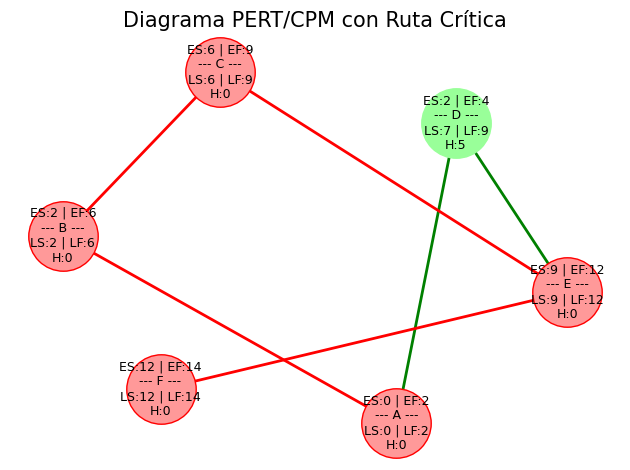

In [9]:
import networkx as nx
import matplotlib.pyplot as plt

grafo = nx.DiGraph()

lista_criticos=[]
lista_normales=[]
informacion={}
for nodo,info in datos.items():
    grafo.add_node(nodo)

    for enlace in info["deps"]:
        grafo.add_edge(enlace,nodo)

    if info["Holgura"]==0:
        lista_criticos.append(nodo)
    else:
        lista_normales.append(nodo)
        
    info = (f"ES:{info['IC']} | EF:{info['TC']}\n"
           f"--- {nodo} ---\n"
           f"LS:{info['IL']} | LF:{info['TL']}\n"
           f"H:{info['Holgura']}")

    informacion[nodo]=info

posiciones = nx.spring_layout(grafo, k=10, seed=50)

print(f"Número de vértices: {grafo.number_of_nodes()}")
print(f"Vértices: {grafo.nodes}")
print(f"Número de aristas: {grafo.number_of_edges()}")
print(f"Vértices: {grafo.edges}")

# 6. Dibujar los Nodos (draw_networkx_nodes)
# Nodos Críticos (Rojo)
nx.draw_networkx_nodes(grafo, posiciones, 
                       nodelist=lista_criticos, 
                       node_color='#ff9999', # Rojo suave
                       node_size=2500, 
                       node_shape='o', 
                       edgecolors='red')

# Nodos Normales (Azul/Verde)
nx.draw_networkx_nodes(grafo, posiciones, 
                       nodelist=lista_normales, 
                       node_color='#99ff99', # Verde suave
                       node_size=2500, 
                       node_shape='o')

aristas_criticas = [(u, v) for u, v in grafo.edges() if u in lista_criticos and v in lista_criticos]
aristas_normales = [(u, v) for u, v in grafo.edges() if (u, v) not in aristas_criticas]

nx.draw_networkx_edges(grafo, posiciones, edgelist=aristas_normales, edge_color='green', width=2, arrows=True)
nx.draw_networkx_edges(grafo, posiciones, edgelist=aristas_criticas, edge_color='red', width=2, arrows=True)

# 8. Dibujar las Etiquetas (Datos alrededor/dentro)
nx.draw_networkx_labels(grafo, posiciones, labels=informacion, font_size=9, font_family="sans-serif")

plt.title("Diagrama PERT/CPM con Ruta Crítica", fontsize=15)
plt.axis('off') # Ocultar ejes X e Y
plt.tight_layout()
plt.show()

f) Genera un diagrama Gantt del proyecto. Para ello, importaremos la librería plotly.express y de la librería datetime utilizaremos datetime y timedelta.

In [10]:
import pandas as pd
import plotly.express as px
from datetime import datetime, timedelta

# 2. Definir una fecha de inicio del proyecto (ej. Hoy)
fecha_inicio_proyecto = datetime.now().replace(hour=0, minute=0, second=0, microsecond=0)

# 3. Preparar los datos para Plotly (Convertir a DataFrame con Fechas)
lista_tareas = []

for tarea, info in datos.items():
    # Calculamos fechas reales sumando los días (timedelta) a la fecha base
    inicio_real = fecha_inicio_proyecto + timedelta(days=info['IC'])
    fin_real = fecha_inicio_proyecto + timedelta(days=info['TC'])
    
    # Determinamos si es Crítica para el color
    tipo_ruta = "Crítica" if info['Holgura'] == 0 else "Normal"
    
    lista_tareas.append({
        'Tarea': tarea,
        'Inicio': inicio_real,
        'Fin': fin_real,
        'Duracion': info['dur'],
        'Holgura': info['Holgura'],
        'Tipo': tipo_ruta
    })

df_gantt = pd.DataFrame(lista_tareas)

# 4. Generar el Gráfico con Plotly Express
fig = px.timeline(
    df_gantt, 
    x_start="Inicio", 
    x_end="Fin", 
    y="Tarea",
    color="Tipo",  # Colorear según si es crítica o no
    title="Diagrama de Gantt del Proyecto (CPM)",
    hover_data=["Duracion", "Holgura"], # Datos extra al pasar el ratón
    color_discrete_map={"Crítica": "#FF5733", "Normal": "#33C1FF"}, # Rojo y Azul
    text="Duracion" # Muestra la duración dentro de la barra
)

# 5. Ajustes visuales para que "Quede bien"
fig.update_layout(
    xaxis_title="Fecha (Calendario)",
    yaxis_title="Tareas",
    showlegend=True,
    yaxis={'autorange': "reversed"} # IMPORTANTE: Invierte el eje Y para que 'A' salga arriba
)

# Ajustar la posición del texto dentro de las barras
fig.update_traces(textposition='inside')
fig.show()

- g) Responde a las siguientes preguntas:
    1. ¿Qué tareas forman el camino crítico?
        - El camino crítico está formado por las tareas: $A \rightarrow B \rightarrow C \rightarrow E \rightarrow F$
    3. ¿Qué tareas tienen holgura?
        - La única que tiene holgura es la D; $H=5$
    5. ¿Qué pasaría si la tarea D se retrasa 1 día?
        - Nada, tiene de margen 5 días de rechazo para que suceda algo
    7. ¿Cuál es la duración mínima del proyecto?
        - 14 semanas (la duración máxima de la ruta crítica)
    8. Si la tarea D dura 5 días, ¿qué ocurre? ¿Puede cambiar el camino crítico?
        - No, debería de durar más de 7 días para verse afectado el camino crítico. Tendríamos un camino $(A \rightarrow D \rightarrow E \rightarrow F)$ de 12 días, inferior a 14.